In [67]:
import pandas as pd
import numpy as np 

In [68]:
df_train=pd.read_csv("train.csv")
df_train.head()


/tmp/ipykernel_33677/2720609938.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train=pd.read_csv("train.csv")


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [69]:
df_train.shape

(100000, 28)

In [70]:
df_train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

# Data Preprocessing 

In [71]:
df_train['Occupation'].unique()

array(['Scientist', '_______', 'Teacher', 'Engineer', 'Entrepreneur',
       'Developer', 'Lawyer', 'Media_Manager', 'Doctor', 'Journalist',
       'Manager', 'Accountant', 'Musician', 'Mechanic', 'Writer',
       'Architect'], dtype=object)

In [72]:
df_train['Occupation']=df_train['Occupation'].str.replace('_______','Others',regex='True')
df_train['Occupation'].unique()

array(['Scientist', 'Others', 'Teacher', 'Engineer', 'Entrepreneur',
       'Developer', 'Lawyer', 'Media_Manager', 'Doctor', 'Journalist',
       'Manager', 'Accountant', 'Musician', 'Mechanic', 'Writer',
       'Architect'], dtype=object)

In [73]:
df_train['Payment_Behaviour']=df_train['Payment_Behaviour'].str.replace('!@9#%8','Unknown_Behavior',regex='True')

In [74]:
df_train['Payment_Behaviour'].unique()

array(['High_spent_Small_value_payments',
       'Low_spent_Large_value_payments',
       'Low_spent_Medium_value_payments',
       'Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments', 'Unknown_Behavior',
       'High_spent_Large_value_payments'], dtype=object)

In [75]:
#removing unwanted columns in the data
cols_to_drop =[
    'ID','Customer_ID','Name','SSN'
]

In [76]:
df_train.drop(columns =cols_to_drop,inplace=True)
df_train.shape

(100000, 24)

In [77]:
#check the missing values percentage of each attribute
check_missing= df_train.isnull().sum()*100/df_train.shape[0]
check_missing[check_missing>0].sort_values(ascending=False)

Monthly_Inhand_Salary      15.002
Type_of_Loan               11.408
Credit_History_Age          9.030
Num_of_Delayed_Payment      7.002
Amount_invested_monthly     4.479
Num_Credit_Inquiries        1.965
Monthly_Balance             1.200
dtype: float64

In [78]:
#drop categorical data that have 1 & 0 category and have a lot of category
df_train.select_dtypes(include='object').nunique()


Month                          8
Age                         1788
Occupation                    16
Annual_Income              18940
Num_of_Loan                  434
Type_of_Loan                6260
Num_of_Delayed_Payment       749
Changed_Credit_Limit        4384
Credit_Mix                     4
Outstanding_Debt           13178
Credit_History_Age           404
Payment_of_Min_Amount          3
Amount_invested_monthly    91049
Payment_Behaviour              7
Monthly_Balance            98792
Credit_Score                   3
dtype: int64

In [79]:
df_train.dtypes

Month                        object
Age                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score                 object
dtype: object

In [80]:
df_train['Age'] = df_train['Age'].str.replace(r'\D', '')
df_train['Annual_Income'] = df_train['Annual_Income'].str.replace(r'\D', '')
df_train['Num_of_Loan'] = df_train['Num_of_Loan'].str.replace(r'\D', '')
df_train['Num_of_Delayed_Payment'] = df_train['Num_of_Delayed_Payment'].str.replace(r'\D', '')
df_train['Changed_Credit_Limit'] = df_train['Changed_Credit_Limit'].str.replace(r'\D', '')
df_train['Outstanding_Debt'] = df_train['Outstanding_Debt'].str.replace(r'\D', '')
df_train['Amount_invested_monthly'] = df_train['Amount_invested_monthly'].str.replace(r'\D', '')
df_train['Monthly_Balance'] = df_train['Monthly_Balance'].str.replace(r'\D', '')

In [81]:
df_train

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,January,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,February,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,March,-500,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,April,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,May,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,April,25,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,NaN,Poor
99996,May,25,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,NaN,Poor
99997,June,25,Mechanic,39628.99,3359.415833,4,6,5729,2,"Auto Loan, and Student Loan",...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,NaN,Poor
99998,July,25,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",...,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,NaN,Standard


In [82]:
df_train.drop(columns = 'Type_of_Loan' , inplace = True) 
df_train.shape

(100000, 23)

In [83]:
df_train.drop(columns = 'Credit_History_Age' , inplace = True)
df_train.shape

(100000, 22)

In [84]:
#convertion of object datatype into integer 
df_train['Age'] = pd.to_numeric(df_train['Age'], errors='coerce', downcast='integer')
df_train['Annual_Income']=pd.to_numeric(df_train['Annual_Income'],errors='coerce', downcast='integer')
df_train['Num_of_Loan']=pd.to_numeric(df_train['Num_of_Loan'],errors='coerce', downcast='integer')
df_train['Num_of_Delayed_Payment']=pd.to_numeric(df_train['Num_of_Delayed_Payment'],errors='coerce', downcast='integer')
df_train['Changed_Credit_Limit']=pd.to_numeric(df_train['Changed_Credit_Limit'],errors='coerce', downcast='integer')
df_train['Outstanding_Debt']=pd.to_numeric(df_train['Outstanding_Debt'],errors='coerce', downcast='integer')
df_train['Amount_invested_monthly']=pd.to_numeric(df_train['Amount_invested_monthly'],errors='coerce', downcast='integer')


In [85]:
df_train.dtypes

Month                        object
Age                         float64
Occupation                   object
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                 float64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score                 object
dtype: object

In [31]:
df_train

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,January,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,3,...,4.0,_,809.98,26.822620,No,49.574949,80.415295,High_spent_Small_value_payments,312.49408867943663,Good
1,February,23.0,Scientist,19114.12,NaN,3,4,3,4.0,-1,...,4.0,Good,809.98,31.944960,No,49.574949,118.280222,Low_spent_Large_value_payments,284.62916249607184,Good
2,March,-500.0,Scientist,19114.12,NaN,3,4,3,4.0,3,...,4.0,Good,809.98,28.609352,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.2098628537912,Good
3,April,23.0,Scientist,19114.12,NaN,3,4,3,4.0,5,...,4.0,Good,809.98,31.377862,No,49.574949,199.458074,Low_spent_Small_value_payments,223.45130972736786,Good
4,May,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,6,...,4.0,Good,809.98,24.797347,No,49.574949,41.420153,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,April,25.0,Mechanic,39628.99,3359.415833,4,6,7,2.0,23,...,3.0,_,502.38,34.663572,No,35.104023,60.971333,High_spent_Large_value_payments,NaN,Poor
99996,May,25.0,Mechanic,39628.99,3359.415833,4,6,7,2.0,18,...,3.0,_,502.38,40.565631,No,35.104023,54.185950,High_spent_Medium_value_payments,NaN,Poor
99997,June,25.0,Mechanic,39628.99,3359.415833,4,6,5729,2.0,27,...,3.0,Good,502.38,41.255522,No,35.104023,24.028477,High_spent_Large_value_payments,NaN,Poor
99998,July,25.0,Mechanic,39628.99,3359.415833,4,6,7,2.0,20,...,3.0,Good,502.38,33.638208,No,35.104023,251.672582,Low_spent_Large_value_payments,NaN,Standard


In [32]:
df_train.drop(columns = 'Monthly_Balance', inplace = True) 
df_train.shape

(100000, 21)

In [33]:
df_train.dtypes

Month                        object
Age                         float64
Occupation                   object
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                 float64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Credit_Score                 object
dtype: object

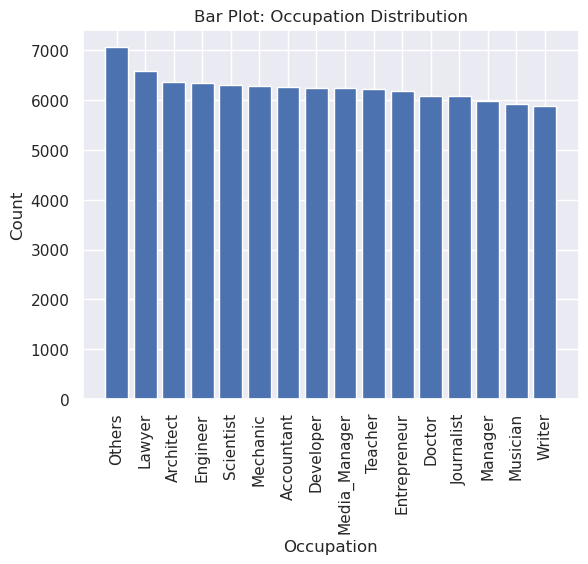

In [100]:
import matplotlib.pyplot as plt

# Count the occurrences of each 'Occupation' and create a bar plot
occupation_counts = df_train['Occupation'].value_counts()
plt.bar(occupation_counts.index, occupation_counts.values)
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.title('Bar Plot: Occupation Distribution')
plt.xticks(rotation=90)
plt.show()

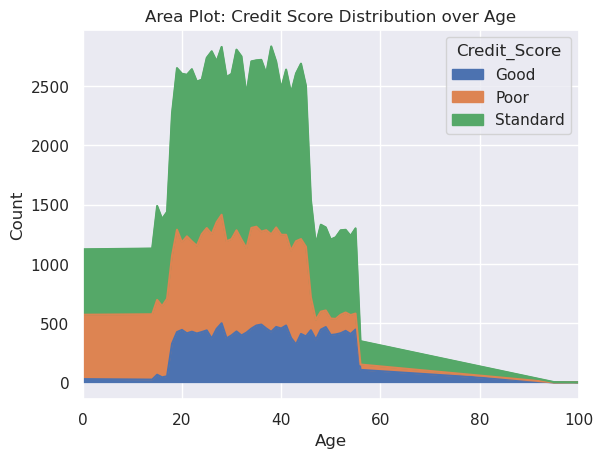

In [104]:
# Create an area plot of 'Credit_Score' distribution over 'Age'
import matplotlib.pyplot as plt
age_groups = df_train.groupby('Age')['Credit_Score'].value_counts().unstack().fillna(0)
age_groups.plot.area(stacked=True)
plt.xlabel('Age')
plt.xlim(0,100)
plt.ylabel('Count')
plt.title('Area Plot: Credit Score Distribution over Age')
plt.show()

<AxesSubplot:xlabel='Credit_Score', ylabel='Age'>

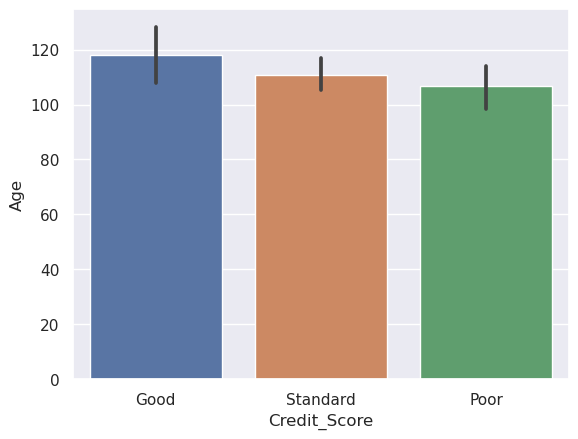

In [35]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.set_theme(color_codes=True)
sns.barplot(data=df_train,x="Credit_Score",y="Age")

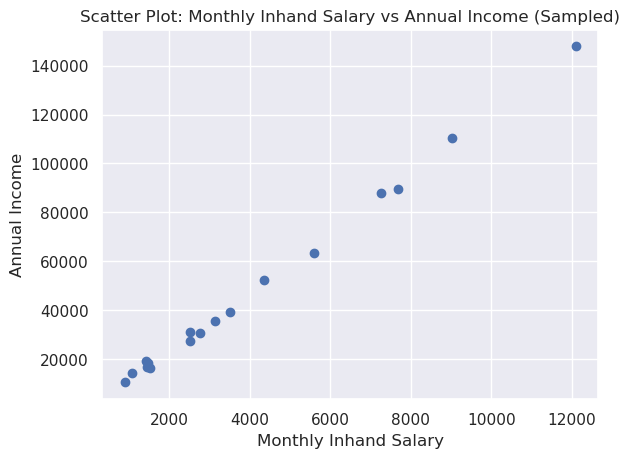

In [87]:
import matplotlib.pyplot as plt
# Take a random sample of 20 rows from the dataframe
sample_df = df_train.sample(n=20)
# Create a scatter plot using the sampled data
plt.scatter(sample_df['Monthly_Inhand_Salary'], sample_df['Annual_Income'])
plt.xlabel('Monthly Inhand Salary')
plt.ylabel('Annual Income')
plt.title('Scatter Plot: Monthly Inhand Salary vs Annual Income (Sampled)')
plt.show()

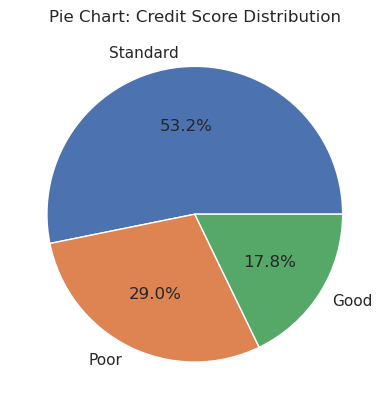

In [88]:
import matplotlib.pyplot as plt

# Calculate the distribution of 'Credit_Score' and create a pie chart
credit_score_counts = df_train['Credit_Score'].value_counts()
plt.pie(credit_score_counts, labels=credit_score_counts.index, autopct='%1.1f%%')
plt.title('Pie Chart: Credit Score Distribution')
plt.show()

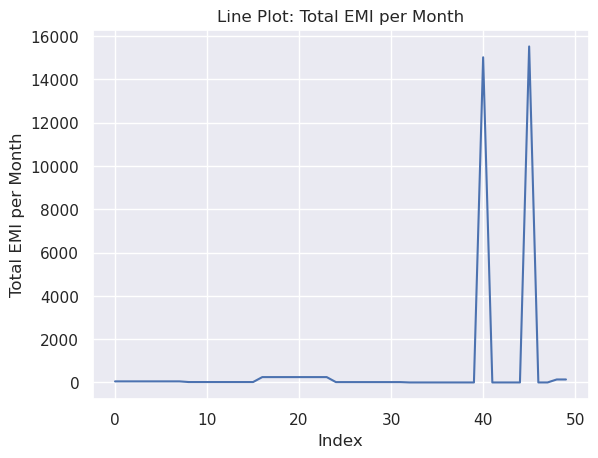

In [89]:
# Create a line plot of 'Total_EMI_per_month'
plt.plot(df_train['Total_EMI_per_month'].head(50))
plt.xlabel('Index')
plt.ylabel('Total EMI per Month')
plt.title('Line Plot: Total EMI per Month')
plt.show()

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 [Text(0, 0, 'Scientist'),
  Text(1, 0, 'Others'),
  Text(2, 0, 'Teacher'),
  Text(3, 0, 'Engineer'),
  Text(4, 0, 'Entrepreneur'),
  Text(5, 0, 'Developer'),
  Text(6, 0, 'Lawyer'),
  Text(7, 0, 'Media_Manager'),
  Text(8, 0, 'Doctor'),
  Text(9, 0, 'Journalist'),
  Text(10, 0, 'Manager'),
  Text(11, 0, 'Accountant'),
  Text(12, 0, 'Musician'),
  Text(13, 0, 'Mechanic'),
  Text(14, 0, 'Writer'),
  Text(15, 0, 'Architect')])

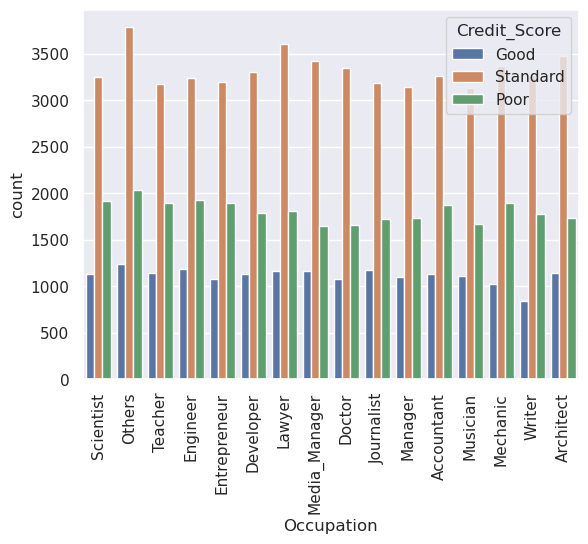

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(color_codes=True)
sns.countplot(data=df_train,x="Occupation",hue="Credit_Score")
plt.xticks(rotation="vertical")

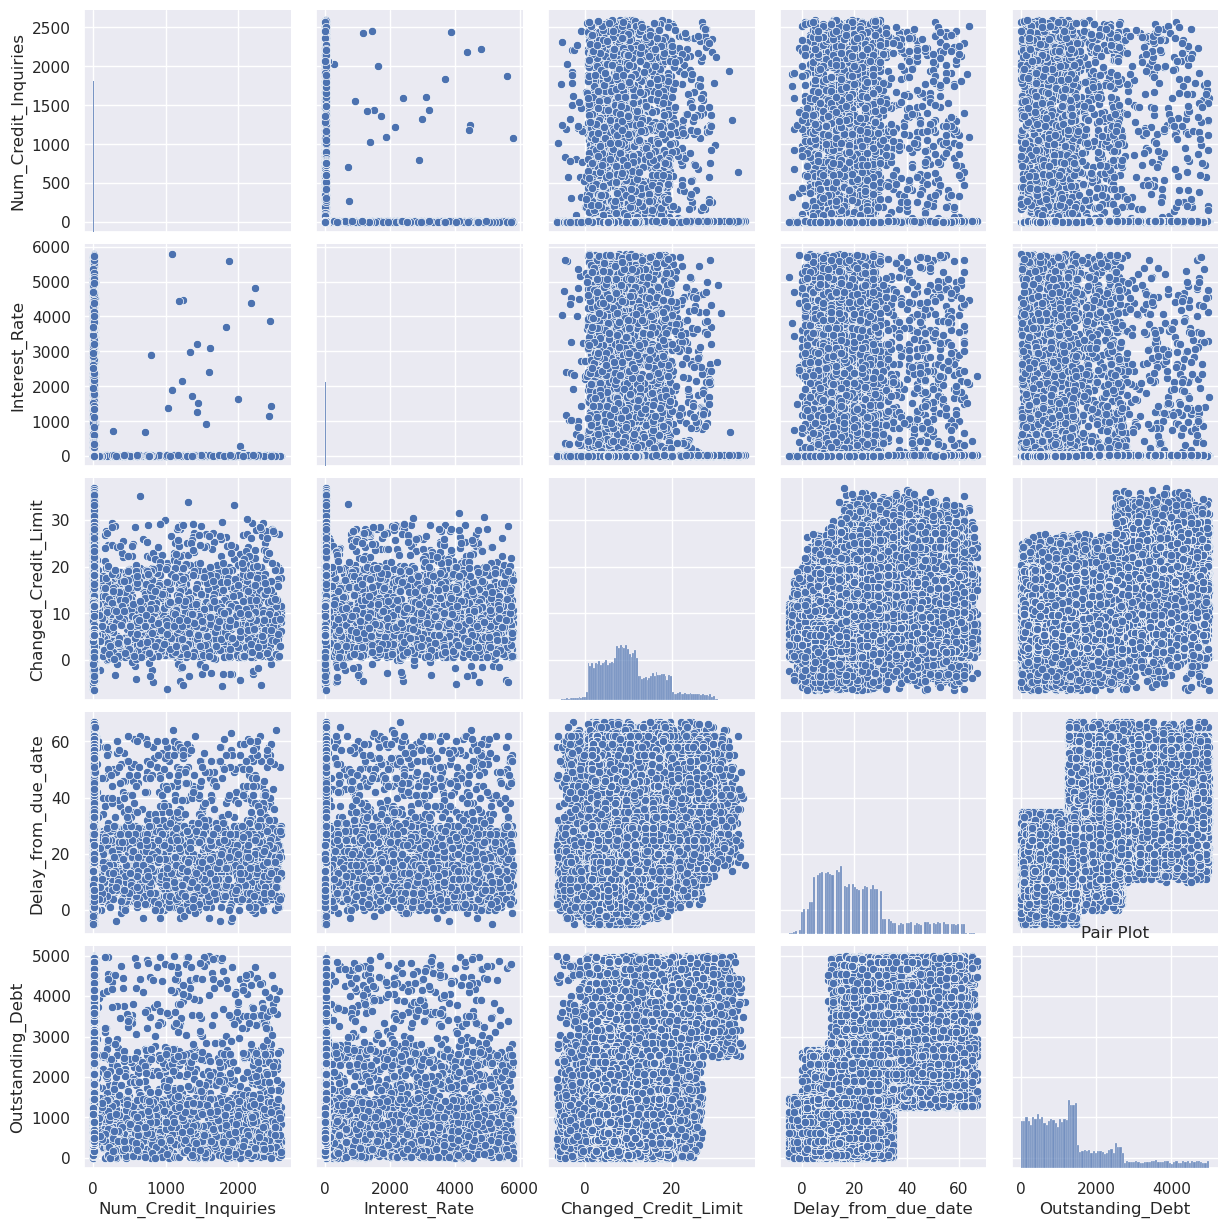

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select a subset of columns for the pair plot
columns = ['Num_Credit_Inquiries',
'Interest_Rate', 'Changed_Credit_Limit', 'Delay_from_due_date', 'Outstanding_Debt']

# Create a pair plot
sns.pairplot(df_train[columns])
plt.title('Pair Plot')
plt.show()

In [36]:
df_train.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Credit_Score
0,January,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,3,...,11.27,4.0,_,809.98,26.822620,No,49.574949,80.415295,High_spent_Small_value_payments,Good
1,February,23.0,Scientist,19114.12,NaN,3,4,3,4.0,-1,...,11.27,4.0,Good,809.98,31.944960,No,49.574949,118.280222,Low_spent_Large_value_payments,Good
2,March,-500.0,Scientist,19114.12,NaN,3,4,3,4.0,3,...,NaN,4.0,Good,809.98,28.609352,No,49.574949,81.699521,Low_spent_Medium_value_payments,Good
3,April,23.0,Scientist,19114.12,NaN,3,4,3,4.0,5,...,6.27,4.0,Good,809.98,31.377862,No,49.574949,199.458074,Low_spent_Small_value_payments,Good
4,May,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,6,...,11.27,4.0,Good,809.98,24.797347,No,49.574949,41.420153,High_spent_Medium_value_payments,Good


In [37]:
df_train.drop(columns="Month",inplace=True)
df_train.shape

(100000, 20)

In [38]:
df_train["Occupation"].unique()

array(['Scientist', 'Others', 'Teacher', 'Engineer', 'Entrepreneur',
       'Developer', 'Lawyer', 'Media_Manager', 'Doctor', 'Journalist',
       'Manager', 'Accountant', 'Musician', 'Mechanic', 'Writer',
       'Architect'], dtype=object)

In [39]:
from sklearn import preprocessing
label_encoder =preprocessing.LabelEncoder()
df_train['Occupation']=label_encoder.fit_transform(df_train['Occupation'])
df_train["Occupation"].unique()

array([13, 12, 14,  4,  5,  2,  7, 10,  3,  6,  8,  0, 11,  9, 15,  1])

In [40]:
df_train["Credit_Mix"].unique()

array(['_', 'Good', 'Standard', 'Bad'], dtype=object)

In [41]:
df_train['Credit_Mix']=label_encoder.fit_transform(df_train['Credit_Mix'])
df_train["Credit_Mix"].unique()

array([3, 1, 2, 0])

In [42]:
df_train['Payment_of_Min_Amount']=label_encoder.fit_transform(df_train['Payment_of_Min_Amount'])
df_train["Payment_of_Min_Amount"].unique()

array([1, 0, 2])

In [43]:
df_train['Payment_Behaviour'].unique()

array(['High_spent_Small_value_payments',
       'Low_spent_Large_value_payments',
       'Low_spent_Medium_value_payments',
       'Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments', 'Unknown_Behavior',
       'High_spent_Large_value_payments'], dtype=object)

In [44]:
df_train['Payment_Behaviour']=label_encoder.fit_transform(df_train['Payment_Behaviour'])
df_train["Payment_Behaviour"].unique()

array([2, 3, 4, 5, 1, 6, 0])

In [45]:
df_train['Credit_Score'].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

In [46]:
df_train['Credit_Score']=label_encoder.fit_transform(df_train['Credit_Score'])
df_train["Credit_Score"].unique()
# 0 -> Good
# 1 -> Poor
# 2 ->  Standard

array([0, 2, 1])

In [47]:
df_train.dtypes

Age                         float64
Occupation                    int64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                 float64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                    int64
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Payment_of_Min_Amount         int64
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour             int64
Credit_Score                  int64
dtype: object

# Balance the class values

In [50]:
#counting 1 and 0 value in response column
df_train['Credit_Score'].value_counts()

Credit_Score
2    53174
1    28998
0    17828
Name: count, dtype: int64

In [51]:
from sklearn.utils import resample
#create two different dataframe of majotiry and minority class
df_majority =df_train[(df_train['Credit_Score']==2)]
df_minority =df_train[(df_train['Credit_Score']==1)]
df_minority2 =df_train[(df_train['Credit_Score']==0)]
# upsample minority class
df_minority_upsampled=resample(df_minority,
                               replace=True,    #sample with replacement
                               n_samples=53174, #to match majority class
                               random_state=0)  #reproducible reslts
df_minority_upsampled2=resample(df_minority2,
                               replace=True,    #sample with replacement
                               n_samples=53174, #to match majority class
                               random_state=0)  #reproducible reslts
#combine majority class with upsampled minority class
df_original=pd.concat([df_minority_upsampled,df_minority_upsampled2,df_majority])

# Certainly! Here's a clear explanation of each step in the updated code 

1. **Create two different dataframes for majority and minority classes:**
   - The dataframe `df_train` is assumed to be the original dataset.
   - `df_majority` is created by selecting rows from `df_train` where the 'Credit_Score' column has a value of 2, representing the majority class.
   - `df_minority` is created by selecting rows from `df_train` where the 'Credit_Score' column has a value of 1, representing one of the minority classes.
   - `df_minority2` is created similarly for another minority class, with 'Credit_Score' value 0.

2. **Upsample the minority class:**
   - The `resample` function from the `sklearn.utils` module is used to upsample the `df_minority` dataframe. Upsampling involves randomly duplicating samples from the minority class to increase its representation.
   - `replace=True` indicates that resampling should be done with replacement, allowing duplicate samples to be selected.
   - `n_samples` is set to 53174, which is the number of samples in the majority class (df_majority). This ensures the upsampled minority class matches the size of the majority class.
   - `random_state=0` ensures that the results of resampling are reproducible.

3. **Upsample the second minority class:**
   - The same upsampling process is repeated for `df_minority2` to upsample the other minority class. The resulting upsampled dataframe is stored in `df_minority_upsampled2`.

4. **Combine majority class with upsampled minority classes:**
   - The `pd.concat()` function is used to concatenate the upsampled minority dataframes (`df_minority_upsampled` and `df_minority_upsampled2`) with the original majority class dataframe (`df_majority`).
   - By combining these dataframes, the resulting `df_original` dataframe contains a balanced representation of the minority and majority classes.

This approach of upsampling the minority classes helps address class imbalance in the dataset, which can improve the performance of machine learning models, especially when the minority class is underrepresented. The resulting `df_original` dataframe can be used for further analysis or training machine learning models.

In [52]:
df_original

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Credit_Score
9152,26.0,5,54275.880,4758.990000,7,10,30,6.0,16,16.0,4.04,10.0,0,4569.66,35.390935,2,192.165937,78.672308,0,1
36712,44.0,12,7226.435,662.202917,8,5,20,613.0,13,15.0,8.72,9.0,2,1533.48,27.876525,2,16.193507,16.422545,0,1
33570,25.0,0,8079.460,NaN,7,7,23,5.0,24,16.0,13.76,11.0,3,1515.52,23.507905,2,25.585426,35.000003,3,1
67473,43.0,1,51266.340,NaN,6,6,24,7.0,19,21.0,26.79,10.0,3,4895.58,26.107994,2,176.470206,74.100638,6,1
44343,22.0,3,13100.020,1246.668333,7,5,6,5.0,6,20.0,10.64,13.0,2,727.29,37.332404,2,41.177132,95.549549,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99989,28.0,12,20002.880,1929.906667,10,8,29,5.0,33,25.0,16.31,9.0,0,3571.70,33.359987,2,60.964772,74.366603,6,2
99990,28.0,1,20002.880,1929.906667,10,8,29,5.0,33,26.0,18.31,9.0,0,3571.70,25.123535,2,60.964772,173.275503,3,2
99991,29.0,1,20002.880,1929.906667,10,8,29,5.0,33,25.0,18.31,9.0,0,3571.70,37.140784,2,60.964772,34.662906,0,2
99993,25.0,9,NaN,3359.415833,4,6,7,2.0,23,NaN,11.50,3.0,1,502.38,29.135447,1,58638.000000,180.733095,4,2


In [53]:
df_original.dropna(inplace=True)
df_original.shape

(89287, 20)

<AxesSubplot:>

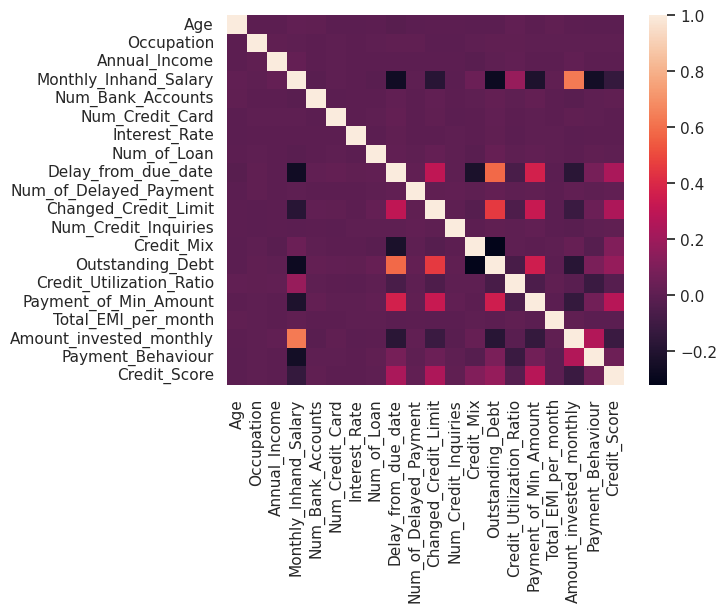

In [54]:
sns.heatmap(df_original.corr(),fmt='.2g')

In [55]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89287 entries, 9152 to 99991
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       89287 non-null  float64
 1   Occupation                89287 non-null  int64  
 2   Annual_Income             89287 non-null  float64
 3   Monthly_Inhand_Salary     89287 non-null  float64
 4   Num_Bank_Accounts         89287 non-null  int64  
 5   Num_Credit_Card           89287 non-null  int64  
 6   Interest_Rate             89287 non-null  int64  
 7   Num_of_Loan               89287 non-null  float64
 8   Delay_from_due_date       89287 non-null  int64  
 9   Num_of_Delayed_Payment    89287 non-null  float64
 10  Changed_Credit_Limit      89287 non-null  float64
 11  Num_Credit_Inquiries      89287 non-null  float64
 12  Credit_Mix                89287 non-null  int64  
 13  Outstanding_Debt          89287 non-null  float64
 14  Credit_U

# machine learning model building


In [56]:
x=df_original.drop('Credit_Score', axis=1)
y=df_original['Credit_Score']

In [57]:
#test size 20% and train size 80%
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

# Decision Tree

In [58]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(random_state=0)
dtree.fit(x_train,y_train)

DecisionTreeClassifier(random_state=0)

In [59]:
y_pred= dtree.predict(x_test)
print('Accuracy score :', round(accuracy_score(y_test,y_pred)*100,2), "%")

Accuracy score : 86.0 %


In [60]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
print('F-1 score : ',(f1_score(y_test,y_pred,average='micro')))
print('Precision score : ',(f1_score(y_test,y_pred,average='micro')))
print('Recall score : ',(f1_score(y_test,y_pred,average='micro')))

F-1 score :  0.8600067196774555
Precision score :  0.8600067196774555
Recall score :  0.8600067196774555


# Random Forest

In [61]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(random_state=0)
rfc.fit(x_train,y_train)

RandomForestClassifier(random_state=0)

In [62]:
y_pred= rfc.predict(x_test)
print('Accuracy score :',round(accuracy_score(y_test,y_pred)*100,2),'%')

Accuracy score : 89.55 %


In [63]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
print('F-1 score : ',(f1_score(y_test,y_pred,average='micro')))
print('Precision score : ',(f1_score(y_test,y_pred,average='micro')))
print('Recall score : ',(f1_score(y_test,y_pred,average='micro')))

F-1 score :  0.8954530182551238
Precision score :  0.8954530182551238
Recall score :  0.8954530182551238


In [64]:
#Feature Importance
imp_df=pd.DataFrame({
    "Feature Name": x_train.columns,
    "Importance": rfc.feature_importances_
})
f1=imp_df.sort_values(by="Importance",ascending=False)
f1

,Feature Name,Importance
13,Outstanding_Debt,0.130969
6,Interest_Rate,0.093553
8,Delay_from_due_date,0.076792
10,Changed_Credit_Limit,0.060008
11,Num_Credit_Inquiries,0.054193
12,Credit_Mix,0.053561
17,Amount_invested_monthly,0.051253
14,Credit_Utilization_Ratio,0.047987
9,Num_of_Delayed_Payment,0.047749
16,Total_EMI_per_month,0.047386


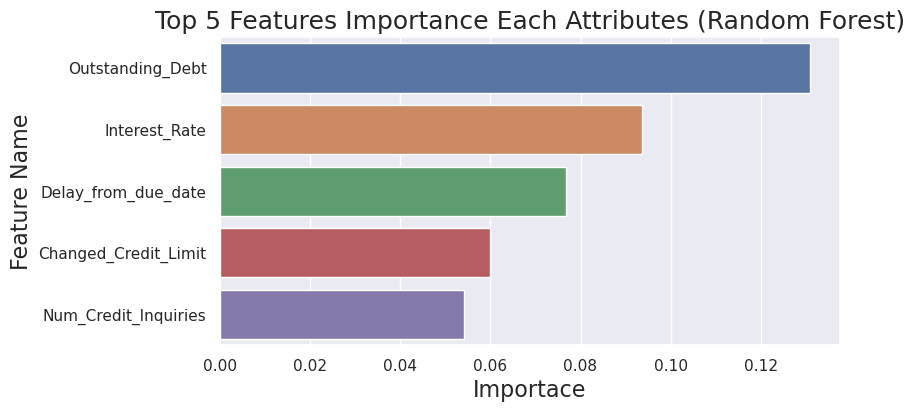

In [108]:
fi2=f1.head(5)
plt.figure(figsize=(8,4))
sns.barplot(data=fi2,x='Importance',y='Feature Name')
plt.title('Top 5 Features Importance Each Attributes (Random Forest)',fontsize=18)
plt.xlabel('Importace',fontsize=16)
plt.ylabel('Feature Name',fontsize=16)
plt.show()